# Exercise 6: Fine-Tuning a Pretrained Language Model

This notebook demonstrates how to fine-tune a pretrained Hugging Face language model on a domain-specific dataset.

Chosen domain: movie reviews
Chosen task: sentiment classification for movie reviews
Chosen model: `distilroberta-base`

The notebook follows these required steps:
1. Identify the task to be performed.
2. Identify the domain used for fine-tuning.
3. Identify the LLM to be used.
4. Establish the configuration needed for fine-tuning.
5. Perform evaluation for the task performed.

In [18]:
%pip install -q transformers datasets evaluate accelerate sentencepiece

Note: you may need to restart the kernel to use updated packages.


In [19]:
import random

import numpy as np
import pandas as pd
import torch
from datasets import DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)

set_seed(42)
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
print("Libraries loaded and seed set.")

Libraries loaded and seed set.


## 1. Identify the task

The task is **movie review sentiment classification**. The model will learn to assign each review to one of two sentiment labels: negative or positive.

In [20]:
task_description = "Fine-tune a pretrained language model to classify movie reviews as positive or negative."
print(task_description)

Fine-tune a pretrained language model to classify movie reviews as positive or negative.


## 2. Identify the domain

The dataset comes from the **movie review** domain. For this notebook, I am using the Hugging Face dataset **rotten_tomatoes**, which contains short movie reviews labeled by sentiment.

In [21]:
dataset_name = "rotten_tomatoes"
raw_dataset = load_dataset(dataset_name)

label_names = raw_dataset["train"].features["label"].names
print("Available labels:", label_names)
print("Train examples:", len(raw_dataset["train"]))
print("Validation examples:", len(raw_dataset["validation"]))
print("Test examples:", len(raw_dataset["test"]))
print(raw_dataset["train"][0])

Available labels: ['neg', 'pos']
Train examples: 8530
Validation examples: 1066
Test examples: 1066
{'text': 'the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'label': 1}


## 3. Identify the LLM

The pretrained model used here is **distilroberta-base**. It is a compact pretrained transformer with a size close to DistilBERT, making it practical for notebook-based fine-tuning while still providing strong language understanding for classification tasks.

In [22]:
model_checkpoint = "distilroberta-base"
id2label = {index: label for index, label in enumerate(label_names)}
label2id = {label: index for index, label in enumerate(label_names)}

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
print("Tokenizer loaded from:", model_checkpoint)
print("Label mapping:", id2label)

Tokenizer loaded from: distilroberta-base
Label mapping: {0: 'neg', 1: 'pos'}


## 4. Establish the fine-tuning configuration

The setup below keeps the run lightweight and notebook-friendly:
- use a moderate batch size,
- train for 1 epoch,
- evaluate every epoch,
- save the best checkpoint using weighted F1.

In [23]:
prepared_dataset = raw_dataset

print(prepared_dataset)
print("Train size:", len(prepared_dataset["train"]))
print("Validation size:", len(prepared_dataset["validation"]))
print("Test size:", len(prepared_dataset["test"]))

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})
Train size: 8530
Validation size: 1066
Test size: 1066


In [24]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True)


tokenized_dataset = prepared_dataset.map(tokenize_batch, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset.set_format("torch")

print(tokenized_dataset["train"][0])

Map:   0%|          | 0/8530 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

Map:   0%|          | 0/1066 [00:00<?, ? examples/s]

{'labels': tensor(1), 'input_ids': tensor([    0,   627,  3152,    16, 19083,     7,    28,     5,   733,   620,
         3220,    18,    92,    22,  2764,   260,    22,     8,    14,    37,
           18,   164,     7,   146,    10, 17158,   190,  2388,    87,  4709,
          282,   279,  8447,  5557,   329, 47129,  2156,  1236, 12001,    12,
         3998,  5247,  3538,  9656,  1794,    50, 11235,  2987,   842,  9487,
          479,     2]), 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1])}


In [25]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

print("Model loaded:", model_checkpoint)
print("Number of labels:", model.config.num_labels)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilroberta-base
Number of labels: 2


In [26]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, predictions),
        "weighted_f1": f1_score(labels, predictions, average="weighted"),
    }


training_args = TrainingArguments(
    output_dir="distilroberta-movie-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,
    report_to="none",
)

print(training_args)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [27]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer is ready.")

Trainer is ready.


## 5. Fine-tune and evaluate

The final steps are:
- train the model,
- evaluate on the validation split,
- check final performance on the test split,
- inspect a few example predictions.

In [28]:
train_result = trainer.train()
print(train_result)

validation_metrics = trainer.evaluate()
print("Validation metrics:", validation_metrics)

c:\Users\Frederick Jibril\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,0.304060,0.347192,0.879925,0.879904


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1067, training_loss=0.4045747182250805, metrics={'train_runtime': 723.7864, 'train_samples_per_second': 11.785, 'train_steps_per_second': 1.474, 'total_flos': 97116196541232.0, 'train_loss': 0.4045747182250805, 'epoch': 1.0})


c:\Users\Frederick Jibril\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Accuracy,Weighted F1
0.304060,0.347192,1,0.879925,0.879904


Validation metrics: {'eval_loss': 0.3471919596195221, 'eval_accuracy': 0.8799249530956847, 'eval_weighted_f1': 0.8799042388396001}


In [29]:
test_predictions = trainer.predict(tokenized_dataset["test"])
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_pred_ids = np.argmax(test_logits, axis=-1)

test_accuracy = accuracy_score(test_labels, test_pred_ids)
test_f1 = f1_score(test_labels, test_pred_ids, average="weighted")

print("Test accuracy:", round(test_accuracy, 4))
print("Test weighted F1:", round(test_f1, 4))
print("\nClassification report:\n")
print(classification_report(test_labels, test_pred_ids, target_names=label_names))
print("Confusion matrix:\n", confusion_matrix(test_labels, test_pred_ids))

c:\Users\Frederick Jibril\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test accuracy: 0.8593
Test weighted F1: 0.8593

Classification report:

              precision    recall  f1-score   support

         neg       0.86      0.86      0.86       533
         pos       0.86      0.86      0.86       533

    accuracy                           0.86      1066
   macro avg       0.86      0.86      0.86      1066
weighted avg       0.86      0.86      0.86      1066

Confusion matrix:
 [[459  74]
 [ 76 457]]


In [30]:
sample_texts = [
    "The movie was touching, well acted, and genuinely funny.",
    "The plot moved along at a steady pace without many surprises.",
    "The film was a boring mess with weak dialogue and no payoff.",
]

encoded_samples = tokenizer(sample_texts, truncation=True, padding=True, return_tensors="pt")
model.eval()
with torch.no_grad():
    sample_outputs = model(**encoded_samples)

sample_predictions = torch.argmax(sample_outputs.logits, dim=-1).tolist()

for text, prediction in zip(sample_texts, sample_predictions):
    print(f"Text: {text}")
    print(f"Predicted sentiment: {id2label[prediction]}")
    print("-")

Text: The movie was touching, well acted, and genuinely funny.
Predicted sentiment: pos
-
Text: The plot moved along at a steady pace without many surprises.
Predicted sentiment: pos
-
Text: The film was a boring mess with weak dialogue and no payoff.
Predicted sentiment: neg
-


## PCA Visualization of Embedding Vectors

The next cell projects 20 known word vectors from the fine-tuned model into 2D using PCA and plots them below.

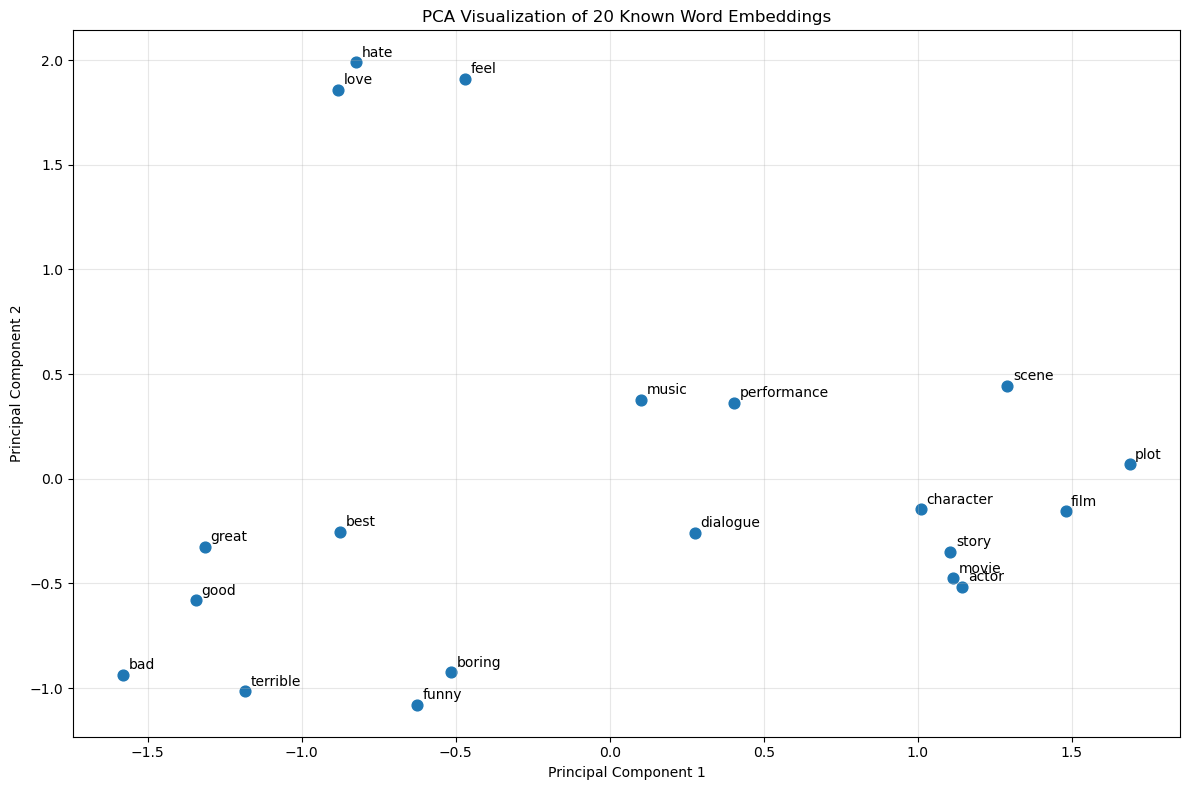

Words plotted: movie, film, story, plot, character, actor, performance, scene, music, dialogue, good, great, best, bad, terrible, funny, boring, love, hate, feel


In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

candidate_words = [
    "movie", "film", "story", "plot", "character", "actor", "performance", "scene", "music", "dialogue",
    "good", "great", "best", "bad", "terrible", "funny", "boring", "love", "hate", "feel",
    "time", "life", "people", "world", "work", "strong", "weak", "simple", "clear", "human",
    "happy", "sad", "day", "night", "think", "know", "make", "see", "look", "write"
]

embedding_matrix = model.get_input_embeddings().weight.detach().cpu()
selected_words = []
selected_tokens = []
selected_vectors = []

for word in candidate_words:
    token_ids = tokenizer.encode(word, add_special_tokens=False)
    if len(token_ids) != 1:
        token_ids = tokenizer.encode(" " + word, add_special_tokens=False)
    if len(token_ids) != 1:
        continue

    token_id = token_ids[0]
    token = tokenizer.convert_ids_to_tokens(token_id)
    display_word = token.lstrip("Ġ")
    if not display_word or display_word in selected_words:
        continue

    selected_words.append(display_word)
    selected_tokens.append(token_id)
    selected_vectors.append(embedding_matrix[token_id].numpy())

    if len(selected_words) >= 20:
        break

if len(selected_words) < 20:
    raise ValueError(f"Only found {len(selected_words)} single-token words for PCA. Need at least 20.")

pca = PCA(n_components=2, random_state=42)
coordinates = pca.fit_transform(np.array(selected_vectors))

plt.figure(figsize=(12, 8))
plt.scatter(coordinates[:, 0], coordinates[:, 1], s=60, color="#1f77b4")

for index, word in enumerate(selected_words):
    plt.annotate(word, (coordinates[index, 0], coordinates[index, 1]), xytext=(4, 4), textcoords="offset points", fontsize=10)

plt.title("PCA Visualization of 20 Known Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Words plotted:", ", ".join(selected_words))

## Summary

This notebook demonstrated:
- the **task**: movie review sentiment classification,
- the **domain**: movie reviews,
- the **LLM**: `distilroberta-base`,
- the **fine-tuning configuration**: tokenizer, train/validation/test splits, training arguments, and metrics,
- the **evaluation**: validation metrics, test metrics, classification report, and confusion matrix.